In [10]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io as sio
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display, Math



root = r'ThingsEEG-Text'
sub = 'sub-09'



# Core directories
brain_dir = fr"{root}/brain_feature/17channels/{sub}"

seen_textual_dir = fr"{root}\textual_feature\ThingsTrain\text\CLIPText\{sub}"
unseen_textual_dir = fr"{root}\textual_feature\ThingsTest\text\CLIPText\{sub}"

seen_visual_dir = fr"{root}\visual_feature\ThingsTrain\pytorch\cornet_s/{sub}"
unseen_visual_dir = fr"{root}\visual_feature\ThingsTest\pytorch\cornet_s\{sub}"

# Seen brain dataset for the individual patient
singular_seen_brain_mat = sio.loadmat(fr"{brain_dir}/eeg_train_data_within.mat")
singular_eeg_seen = singular_seen_brain_mat['data']
singular_seen_labels = singular_seen_brain_mat['class_idx'].flatten()

# Unseen brain dataset for the individual patient
singular_unseen_brain_mat = sio.loadmat(fr"{brain_dir}/eeg_test_data.mat")
singular_eeg_unseen = singular_unseen_brain_mat['data']
singular_unseen_labels = singular_unseen_brain_mat['class_idx'].flatten()

# Unique brain dataset for the individual patient
singular_unique_brain_mat = sio.loadmat(fr"{brain_dir}/eeg_test_data_unique.mat")
singular_eeg_unique = singular_unique_brain_mat['data']
singular_unique_labels = singular_unique_brain_mat['class_idx'].flatten()

# Text seen data
seen_textual_mat = sio.loadmat(fr"{seen_textual_dir}/text_feat_train.mat")
seen_textual = seen_textual_mat['data']

# Text unseen data
unseen_textual_mat = sio.loadmat(fr"{unseen_textual_dir}/text_feat_test.mat")
unseen_textual = unseen_textual_mat['data']

# Text unique data
unique_textual_mat = sio.loadmat(fr"{unseen_textual_dir}/text_feat_test_unique.mat")
unique_textual = unique_textual_mat['data']

# Visual seen data
seen_visual_mat = sio.loadmat(fr"{seen_visual_dir}/feat_pca_train.mat")
seen_visual = seen_visual_mat['data']

# Visual unseen data
unseen_visual_mat = sio.loadmat(fr"{unseen_visual_dir}/feat_pca_test.mat")
unseen_visual = unseen_visual_mat['data']

# Visual unique data
unique_visual_mat = sio.loadmat(fr"{unseen_visual_dir}/feat_pca_test_unique.mat")
unique_visual = unique_visual_mat['data']

print("Singular Patient Seen Data Sample")
print('EEG Data shape:', singular_eeg_seen.shape)
print("EEG labels shape:", singular_seen_labels.shape, "\n")

print("Singular Patient Unseen Data Sample")
print('EEG Data shape:', singular_eeg_unseen.shape)
print("EEG labels shape:", singular_unseen_labels.shape, "\n")

print("Singular Patient Unique Data Sample")
print('EEG Data shape:', singular_eeg_unique.shape)
print("EEG labels shape:", singular_unique_labels.shape, "\n")

print("Textual Seen Data shape:", seen_textual.shape)
print("Textual Unseen Data Shape:", unseen_textual.shape)
print("Textual Unique Data Shape:", unique_textual.shape, "\n")
print("Textual labels: ",unseen_textual_mat.keys())

print("Visual Seen Data shape:", seen_visual.shape)
print("Visual Unseen Data shape:", unseen_visual.shape)
print("Visual Unique Data shape:", unique_visual.shape, "\n")

print("Seen EEG sample stats:")
print("Mean:", singular_eeg_seen.mean())
print("Std:", singular_eeg_seen.std())
print("Min:", singular_eeg_seen.min())
print("Max:", singular_eeg_seen.max())

# Print first trial, first 10 channels/timepoints
print("\nFirst trial snippet:")
print(singular_eeg_seen[0, :5, :10])

print(seen_textual[:20])

#---------------------------------------------------
import numpy as np

unique_classes = np.unique(singular_unique_labels)
print("Number of UNIQUE classes:", len(unique_classes))
print("First few class IDs:", unique_classes[:10])

import numpy as np
from IPython.display import display, Math



latex_str = r"\begin{bmatrix}" + \
            r" \\ ".join([" & ".join(map(str, row)) for row in np.cov(seen_visual[:, :3].T)]) + \
            r"\end{bmatrix}"

display(Math(latex_str))




# print("Number of classes in images:", np.unique(seen_visual, axis=0).shape[0])

# print("Number of classes in textual:", np.unique(seen_textual, axis=0).shape[0])

# print("Number of classes in brain:", np.unique(singular_eeg_seen, axis=0).shape[0])




print("--------------------------------------", "\n")

print("Keys in unseen brain", singular_unseen_brain_mat.keys())

print("Keys in unseen textual", unseen_textual_mat.keys())

print("Keys in unseen visual", unseen_visual_mat.keys())



Singular Patient Seen Data Sample
EEG Data shape: (16540, 17, 100)
EEG labels shape: (16540,) 

Singular Patient Unseen Data Sample
EEG Data shape: (16000, 17, 100)
EEG labels shape: (16000,) 

Singular Patient Unique Data Sample
EEG Data shape: (200, 17, 100)
EEG labels shape: (200,) 

Textual Seen Data shape: (16540, 512)
Textual Unseen Data Shape: (16000, 512)
Textual Unique Data Shape: (200, 512) 

Textual labels:  dict_keys(['__header__', '__version__', '__globals__', 'data'])
Visual Seen Data shape: (16540, 1000)
Visual Unseen Data shape: (16000, 1000)
Visual Unique Data shape: (200, 1000) 

Seen EEG sample stats:
Mean: -0.04088211821042513
Std: 0.410802896489778
Min: -5.291223367175654
Max: 4.34932933960058

First trial snippet:
[[ 0.42260069  0.44445733  0.01640725 -0.37116427 -0.4867265  -0.38750425
  -0.12362779 -0.02100592 -0.14819995 -0.04796079]
 [ 0.2496754   0.31108232  0.08541917  0.00305425 -0.43387917 -0.86516603
  -0.41716751 -0.29719975  0.18209825  0.23475919]
 [ 1

<IPython.core.display.Math object>

-------------------------------------- 

Keys in unseen brain dict_keys(['__header__', '__version__', '__globals__', 'data', 'class_idx'])
Keys in unseen textual dict_keys(['__header__', '__version__', '__globals__', 'data'])
Keys in unseen visual dict_keys(['__header__', '__version__', '__globals__', 'data'])


**Data Analysis**

(1654, 17, 100)
[0.1363264  0.13877259 0.20612502 0.19020865 0.25473413 0.26042756
 0.12299338 0.21781985 0.12994326 0.15979393 0.21822464 0.15321651
 0.13750133 0.20345528 0.21885213 0.15886223 0.12730039]


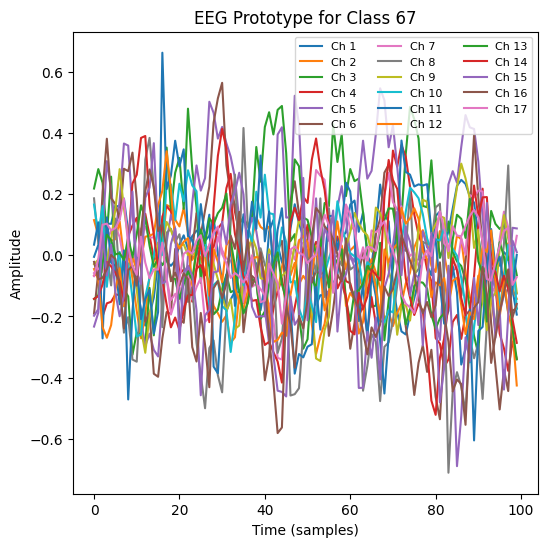

In [12]:
def compute_class_prototypes(features, labels):
    classes = np.unique(labels)
    protos = []
    for c in classes:
        protos.append(features[labels == c].mean(axis=0))
    return np.array(protos), classes

protos, classes = compute_class_prototypes(singular_eeg_seen, singular_seen_labels)
print(protos.shape)
per_channel_std = protos.reshape(-1, 17, 100).std(axis=(0, 2))
print(per_channel_std)

plt.figure(figsize=(6,6))

i = 67   # class index
proto = protos[i]

for ch in range(17):
    plt.plot(proto[ch], label=f"Ch {ch+1}")


plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.title(f"EEG Prototype for Class {i}")
plt.legend(ncol=3, fontsize=8)
plt.show()

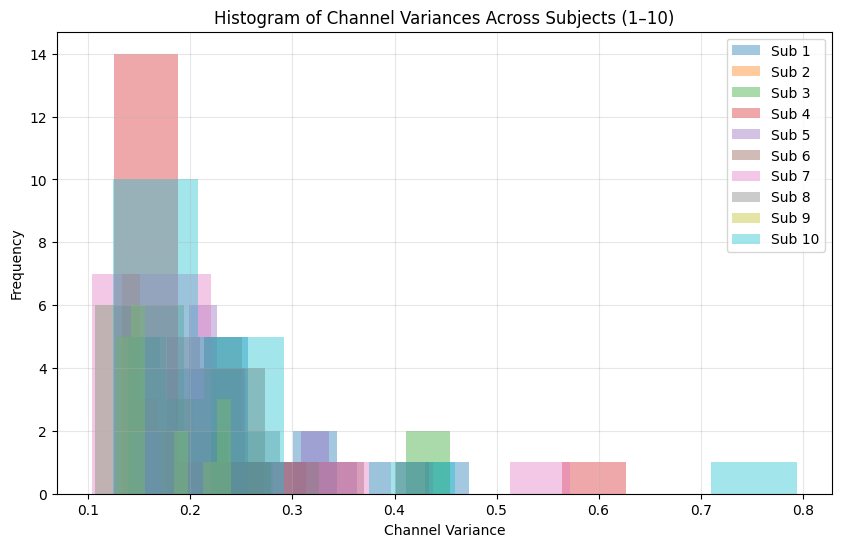

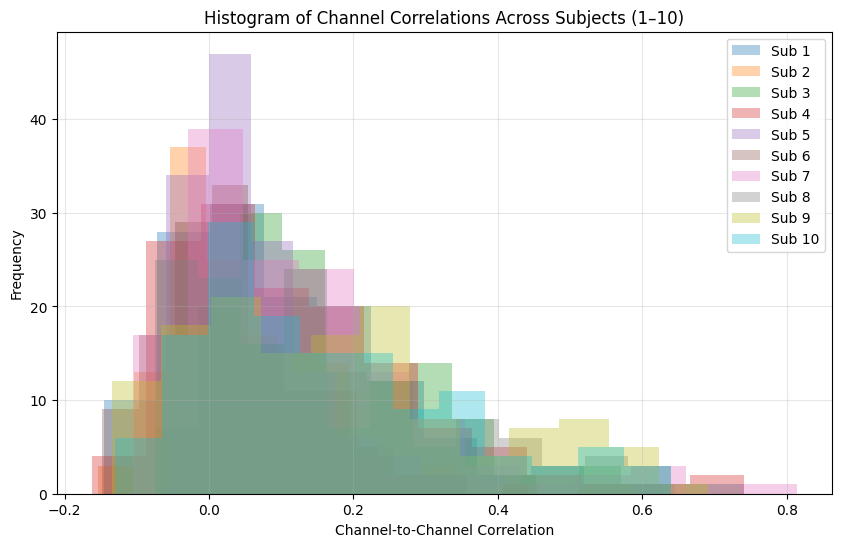

In [14]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------
# CONFIG
# --------------------------------------------

brain_template = r"{root}\brain_feature\17channels\sub-{ID}\eeg_train_data_within.mat"

subjects = range(1, 11)

# colour palette for 10 subjects
palette = sns.color_palette("tab10", 10)

# containers
variance_list = []
corr_list = []

# --------------------------------------------
# PROCESS EACH SUBJECT
# --------------------------------------------
for idx, sub in enumerate(subjects):
    path = brain_template.replace("{root}", root).replace("{ID}", f"{sub:02d}")
    mat = sio.loadmat(path)
    eeg = mat["data"]  # (N,17,100)

    # ---- CHANNEL VARIANCE ----
    ch_var = eeg.var(axis=(0,2))  # (17,)
    variance_list.append(ch_var)

    # ---- CHANNEL CORRELATIONS ----
    avg_channels = eeg.mean(axis=2)   # (N,17)
    corr_mat = np.corrcoef(avg_channels.T)
    off_diag = corr_mat[np.triu_indices(17, k=1)]  # 136 values
    corr_list.append(off_diag)

# --------------------------------------------
# PLOT: Variance Histograms (one colour per subject)
# --------------------------------------------
plt.figure(figsize=(10,6))
for idx, ch_var in enumerate(variance_list):
    plt.hist(
        ch_var,
        bins=8,
        alpha=0.4,
        color=palette[idx],
        label=f"Sub {subjects[idx]}"
    )

plt.xlabel("Channel Variance")
plt.ylabel("Frequency")
plt.title("Histogram of Channel Variances Across Subjects (1–10)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --------------------------------------------
# PLOT: Correlation Histograms (one colour per subject)
# --------------------------------------------
plt.figure(figsize=(10,6))
for idx, corr_vals in enumerate(corr_list):
    plt.hist(
        corr_vals,
        bins=12,
        alpha=0.35,
        color=palette[idx],
        label=f"Sub {subjects[idx]}"
    )

plt.xlabel("Channel-to-Channel Correlation")
plt.ylabel("Frequency")
plt.title("Histogram of Channel Correlations Across Subjects (1–10)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


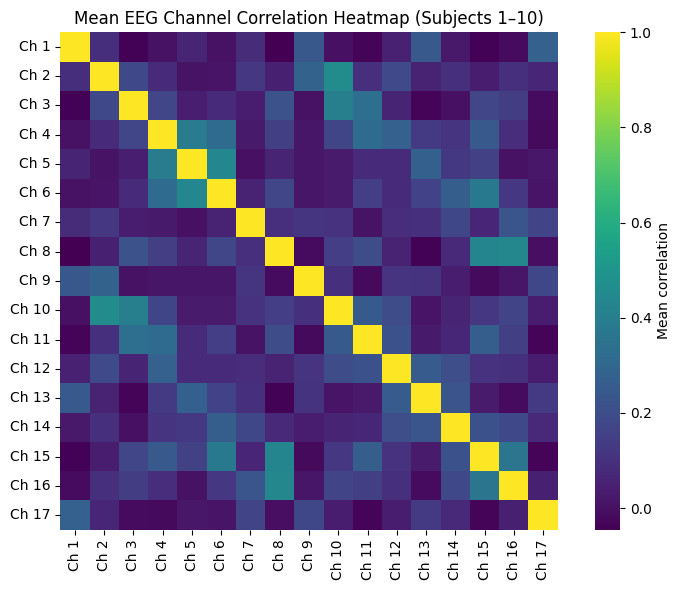

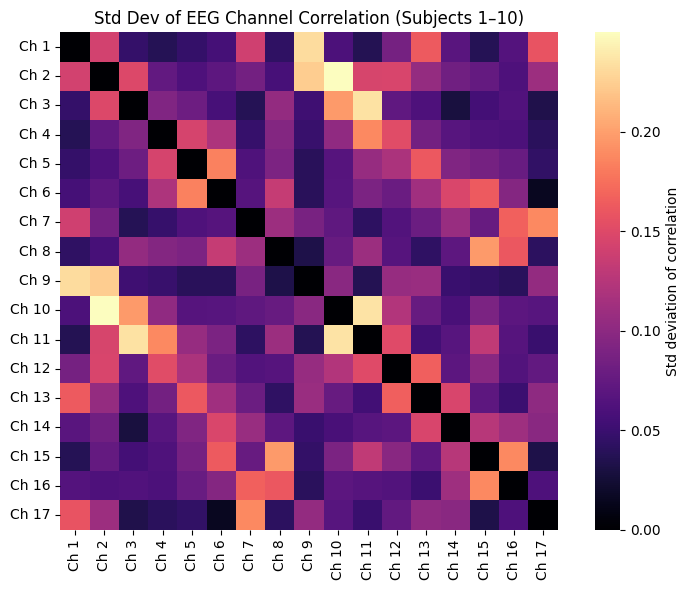

In [15]:
import numpy as np
import scipy.io as sio
import seaborn as sns
import matplotlib.pyplot as plt

# ------------------------------------
# CONFIG
# ------------------------------------

brain_template = r"{root}\brain_feature\17channels\sub-{ID}\eeg_train_data_within.mat"

subjects = range(1, 11)   # subjects 1–10

corr_mats = []  # store all 10 correlation matrices here

# ------------------------------------
# LOAD + COMPUTE CORR FOR EACH SUBJECT
# ------------------------------------
for sub in subjects:
    path = brain_template.replace("{root}", root).replace("{ID}", f"{sub:02d}")
    
    # load EEG
    mat = sio.loadmat(path)
    eeg = mat["data"]   # shape (N, 17, 100)

    # average across timepoints: (N, 17, 100) → (N, 17)
    avg_channels = eeg.mean(axis=2)
    
    # channel correlation: (17 x 17)
    corr = np.corrcoef(avg_channels.T)
    
    corr_mats.append(corr)

# Convert to numpy array: shape (10, 17, 17)
corr_mats = np.array(corr_mats)

# ------------------------------------
# COMPUTE MEAN & STD ACROSS SUBJECTS
# ------------------------------------
mean_corr = corr_mats.mean(axis=0)
std_corr  = corr_mats.std(axis=0)

# ------------------------------------
# PLOT MEAN CORRELATION HEATMAP
# ------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(
    mean_corr,
    cmap='viridis',
    annot=False,
    xticklabels=[f"Ch {i+1}" for i in range(17)],
    yticklabels=[f"Ch {i+1}" for i in range(17)],
    square=True,
    cbar_kws={'label': 'Mean correlation'}
)
plt.title("Mean EEG Channel Correlation Heatmap (Subjects 1–10)")
plt.tight_layout()
plt.show()

# ------------------------------------
# PLOT STANDARD DEVIATION HEATMAP
# ------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(
    std_corr,
    cmap='magma',
    annot=False,
    xticklabels=[f"Ch {i+1}" for i in range(17)],
    yticklabels=[f"Ch {i+1}" for i in range(17)],
    square=True,
    cbar_kws={'label': 'Std deviation of correlation'}
)
plt.title("Std Dev of EEG Channel Correlation (Subjects 1–10)")
plt.tight_layout()
plt.show()


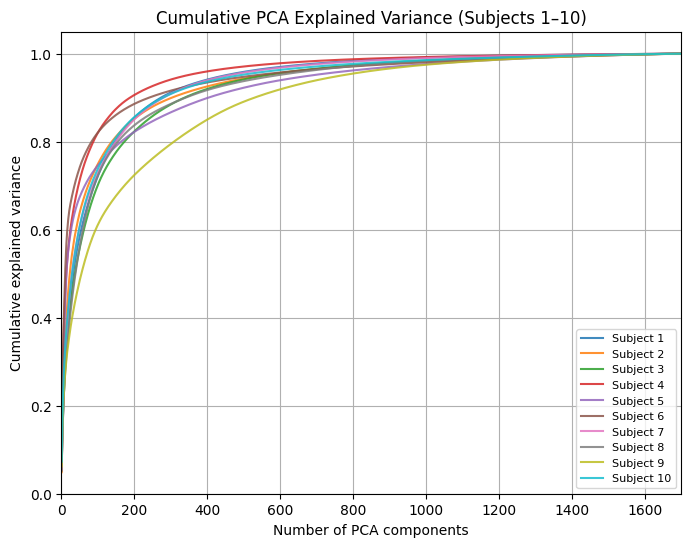

In [16]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --------------------------------------------
# CONFIG
# --------------------------------------------
brain_template = r"{root}\brain_feature\17channels\sub-{ID}\eeg_train_data_within.mat"

subjects = range(1, 11)   # subjects 1–10
colors = plt.cm.tab10(np.linspace(0, 1, len(subjects)))  # 10 distinct colours

plt.figure(figsize=(8, 6))

# --------------------------------------------
# LOOP THROUGH SUBJECTS
# --------------------------------------------
for i, sub in enumerate(subjects):

    # file path
    path = brain_template.replace("{root}", root).replace("{ID}", f"{sub:02d}")

    # load EEG
    mat = sio.loadmat(path)
    eeg = mat["data"]              # shape (N, 17, 100)

    # flatten (N, 17, 100) → (N, 1700)
    flat = eeg.reshape(eeg.shape[0], -1)

    # PCA keeping all components
    pca = PCA()
    pca.fit(flat)

    # cumulative explained variance
    evr = np.cumsum(pca.explained_variance_ratio_)

    # x-axis: number of components
    x = np.arange(1, len(evr)+1)

    # plot subject curve
    plt.plot(x, evr, color=colors[i], label=f"Subject {sub}", alpha=0.85)

# --------------------------------------------
# FIGURE FORMATTING
# --------------------------------------------
plt.title("Cumulative PCA Explained Variance (Subjects 1–10)")
plt.xlabel("Number of PCA components")
plt.ylabel("Cumulative explained variance")
plt.xlim(0, 1700)
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend(fontsize=8)

plt.show()


In [17]:
from sklearn.cross_decomposition import CCA

flattened_x = singular_eeg_seen.reshape(singular_eeg_seen.shape[0],-1)

cca = CCA(n_components=10)
U, V = cca.fit_transform(seen_visual, flattened_x)

corrs = [np.corrcoef(U[:, i], V[:, i])[0, 1] for i in range(10)]
print(corrs)


[np.float64(0.9511978065088473), np.float64(0.8783085120720817), np.float64(0.8095707363102396), np.float64(0.7972577966171641), np.float64(0.7640597547569331), np.float64(0.7510169546483993), np.float64(0.743327590510863), np.float64(0.7121226363048497), np.float64(0.7002557842997897), np.float64(0.6838581958169462)]


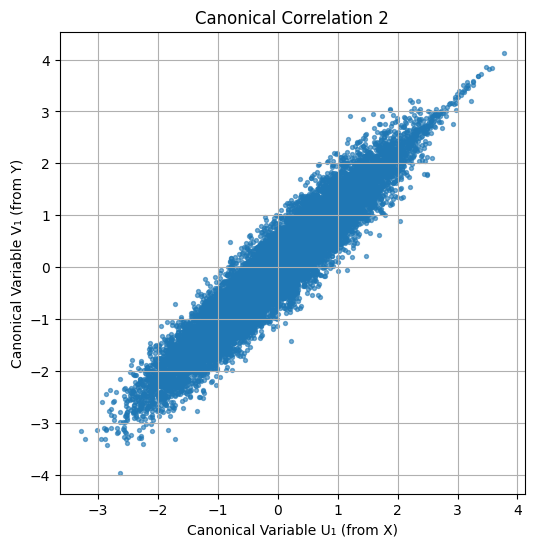

In [18]:


plt.figure(figsize=(6,6))
plt.scatter(U[:,0], V[:,0], alpha=0.6, s=8)
plt.xlabel("Canonical Variable U₁ (from X)")
plt.ylabel("Canonical Variable V₁ (from Y)")
plt.title("Canonical Correlation 2")
plt.grid(True)
plt.show()


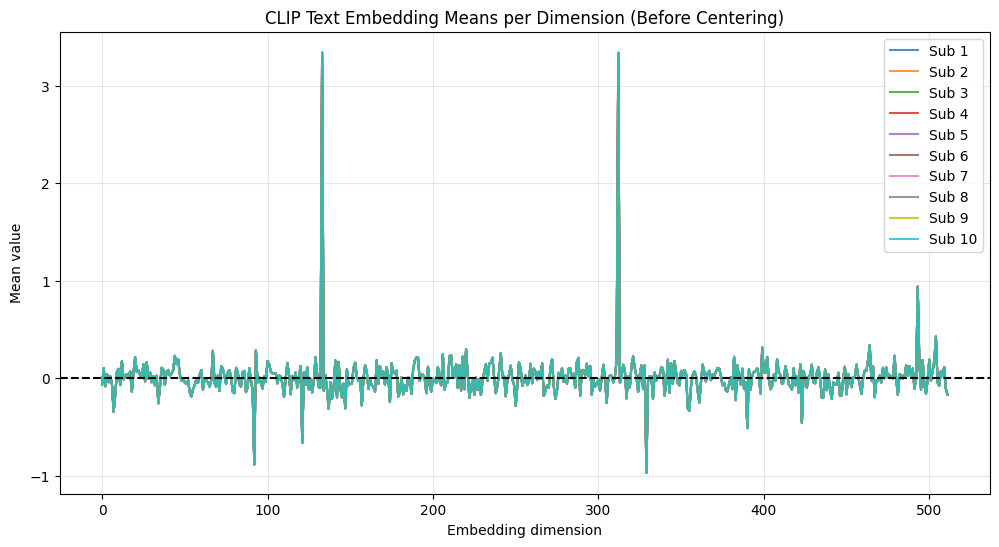

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import seaborn as sns

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------

text_dir_template = r"{root}\textual_feature\ThingsTrain\text\CLIPText\sub-{ID}\text_feat_train.mat"

subjects = range(1, 11)
palette = sns.color_palette("tab10", 10)

# ---------------------------------------------------------
# PLOT SETUP
# ---------------------------------------------------------
plt.figure(figsize=(12,6))

for idx, sub in enumerate(subjects):

    # Build path
    path = text_dir_template.replace("{root}", root).replace("{ID}", f"{sub:02d}")

    # Load .mat file
    mat = sio.loadmat(path)
    text_data = mat["data"]    # shape (N, 512)

    # Compute mean per dimension
    mean_vec = text_data.mean(axis=0)

    # Plot
    plt.plot(mean_vec, color=palette[idx], alpha=0.8, label=f"Sub {sub}")

# ----- Zero line
plt.axhline(0, color='black', linestyle='--')

plt.title("CLIP Text Embedding Means per Dimension (Before Centering)")
plt.xlabel("Embedding dimension")
plt.ylabel("Mean value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()




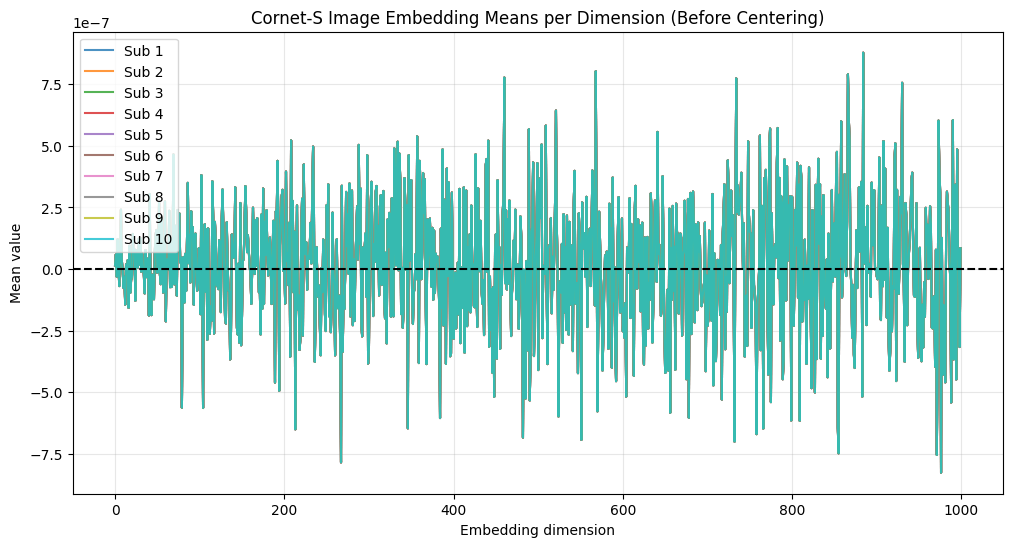

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import seaborn as sns

# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------

img_dir_template = r"{root}\visual_feature\ThingsTrain\pytorch\cornet_s\sub-{ID}\feat_pca_train.mat"

subjects = range(1, 11)
palette = sns.color_palette("tab10", 10)

# ---------------------------------------------------------
# PLOT SETUP
# ---------------------------------------------------------
plt.figure(figsize=(12,6))

for idx, sub in enumerate(subjects):

    path = img_dir_template.replace("{root}", root).replace("{ID}", f"{sub:02d}")

    mat = sio.loadmat(path)
    image_data = mat["data"]   # shape (N, 1000) after PCA

    mean_vec = image_data.mean(axis=0)

    plt.plot(mean_vec, color=palette[idx], alpha=0.8, label=f"Sub {sub}")

plt.axhline(0, color='black', linestyle='--')

plt.title("Cornet-S Image Embedding Means per Dimension (Before Centering)")
plt.xlabel("Embedding dimension")
plt.ylabel("Mean value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**BASELINE**

In [11]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
import pandas as pd

# -------------------------------------------------------
# 1. Helper: class prototypes
# -------------------------------------------------------
def compute_class_prototypes(features, labels):
    classes = np.unique(labels)
    protos = []
    for c in classes:
        protos.append(features[labels == c].mean(axis=0))
    return np.array(protos), classes


# -------------------------------------------------------
# 2. EEG preprocessing helper (FLATTEN ONLY)
# -------------------------------------------------------
def prep_eeg(eeg):
    X = eeg.reshape(eeg.shape[0], -1)   # (N,17,100) → (N,1700)
    return X


# -------------------------------------------------------
# 3. Prepare SEEN EEG (flatten only)
# -------------------------------------------------------
X_seen = singular_eeg_seen.reshape(singular_eeg_seen.shape[0], -1)
y_seen = singular_seen_labels.astype(int)

X_seen_flat = X_seen   # flatten only
print("Seen EEG shape (flatten only):", X_seen_flat.shape)


# -------------------------------------------------------
# 5. Train EEG → TEXT and EEG → IMAGE regressions
# -------------------------------------------------------
reg_text = LinearRegression()
reg_img  = LinearRegression()

reg_text.fit(X_seen_flat, seen_textual)
reg_img.fit(X_seen_flat, seen_visual)

print("Learned EEG→TEXT and EEG→IMAGE mappings (flatten only).")


# -------------------------------------------------------
# 6. Prepare UNSEEN & UNIQUE EEG (flatten only)
# -------------------------------------------------------
X_unseen_std = prep_eeg(singular_eeg_unseen)
X_unique_std = prep_eeg(singular_eeg_unique)

pred_unseen_text = reg_text.predict(X_unseen_std)
pred_unseen_img  = reg_img.predict(X_unseen_std)

pred_unique_text = reg_text.predict(X_unique_std)
pred_unique_img  = reg_img.predict(X_unique_std)

print("Predicted multimodal semantics for unseen & unique EEG.")


# -------------------------------------------------------
# 7. Build centered TEXT & IMAGE prototypes
# -------------------------------------------------------
proto_unseen_text, unseen_classes = compute_class_prototypes(
    unseen_textual, singular_unseen_labels
)
proto_unseen_img, _ = compute_class_prototypes(
    unseen_visual, singular_unseen_labels
)

print("Prototype shapes:")
print("  Unseen text:", proto_unseen_text.shape,
      " Unseen img:", proto_unseen_img.shape)

# -------------------------------------------------------
# 8. Fused cosine NN classifier
# -------------------------------------------------------
def cosine_nn_fused(pred_text, pred_img,
                    proto_text, proto_img,
                    class_ids,
                    w_text=0.5, w_img=0.5):

    preds = []

    proto_text_norms = np.linalg.norm(proto_text, axis=1)
    proto_img_norms  = np.linalg.norm(proto_img, axis=1)

    for vt, vi in zip(pred_text, pred_img):

        sims_text = np.dot(proto_text, vt) / (
            proto_text_norms * (np.linalg.norm(vt) + 1e-8)
        )

        sims_img = np.dot(proto_img, vi) / (
            proto_img_norms * (np.linalg.norm(vi) + 1e-8)
        )

        sims_fused = w_text * sims_text + w_img * sims_img
        preds.append(class_ids[np.argmax(sims_fused)])

    return np.array(preds)


# -------------------------------------------------------
# 9. Zero-shot accuracy (UNSEEN)
# -------------------------------------------------------
y_pred_unseen_fused = cosine_nn_fused(
    pred_unseen_text, pred_unseen_img,
    proto_unseen_text, proto_unseen_img,
    unseen_classes,
    w_text=5, w_img=5
)

acc_unseen_fused = accuracy_score(singular_unseen_labels, y_pred_unseen_fused)
print("Multimodal Zero-Shot Accuracy (UNSEEN, fused):", acc_unseen_fused)


Seen EEG shape (flatten only): (16540, 1700)
Learned EEG→TEXT and EEG→IMAGE mappings (flatten only).
Predicted multimodal semantics for unseen & unique EEG.
Prototype shapes:
  Unseen text: (200, 512)  Unseen img: (200, 1000)
Multimodal Zero-Shot Accuracy (UNSEEN, fused): 0.0575625


**MAIN MODEL**

In [ ]:
import numpy as np
from sklearn.linear_model import RidgeCV
from sklearn.metrics import accuracy_score
import pandas as pd

# -------------------------------------------------------
# 1. Helper: class prototypes
# -------------------------------------------------------
def compute_class_prototypes(features, labels):
    classes = np.unique(labels)
    protos = []
    for c in classes:
        protos.append(features[labels == c].mean(axis=0))
    return np.array(protos), classes

def rolling_zscore(X, window=180):
    df = pd.DataFrame(X)
    roll_mean = df.rolling(window, center=True, min_periods=1).mean()
    roll_std  = df.rolling(window, center=True, min_periods=1).std()

    roll_std = roll_std.fillna(0) + 1e-8  # avoid divide-by-zero
    out = (df - roll_mean) / roll_std
    return out.to_numpy()




# -------------------------------------------------------
# 2. EEG preprocessing helper (NO scaler, NO PCA)
# -------------------------------------------------------
def prep_eeg(eeg, window=180):
    X = eeg.reshape(eeg.shape[0], -1)        # flatten EEG
    X_rz = rolling_zscore(X, window=window)  # rolling z-score only
    return X_rz



# -------------------------------------------------------
# 3. Prepare SEEN EEG (flatten + rolling z-score)
# -------------------------------------------------------
X_seen = singular_eeg_seen.reshape(singular_eeg_seen.shape[0], -1)
y_seen = singular_seen_labels.astype(int)

X_seen_rz = rolling_zscore(X_seen)   # NO scaler
X_seen_std = X_seen_rz               # rename for compatibility

print("Seen EEG shape (rolling-zscore only):", X_seen_std.shape)


# -------------------------------------------------------
# 4. Center TEXT & IMAGE using only SEEN means
# -------------------------------------------------------
text_mean = seen_textual.mean(axis=0)
visual_mean = seen_visual.mean(axis=0)

seen_textual_c   = seen_textual   - text_mean
unseen_textual_c = unseen_textual - text_mean

seen_visual_c   = seen_visual   - visual_mean
unseen_visual_c = unseen_visual - visual_mean


# -------------------------------------------------------
# 5. Train EEG → TEXT and EEG → IMAGE regressions
# -------------------------------------------------------


alphas = np.array([1, 3, 10, 30, 50, 100, 300, 500, 800, 1000, 2000, 3000, 1e4])

reg_text = RidgeCV(alphas=alphas, cv=5, scoring="neg_mean_squared_error")
reg_img  = RidgeCV(alphas=alphas, cv=5, scoring="neg_mean_squared_error")


reg_text.fit(X_seen_std, seen_textual_c)
reg_img.fit(X_seen_std, seen_visual_c)

print("Learned EEG→TEXT and EEG→IMAGE mappings (NO scaler).")
print("Chosen alpha text:", reg_text.alpha_)
print("Chosen alpha img :", reg_img.alpha_)


# -------------------------------------------------------
# 6. Prepare UNSEEN EEG (rolling z-score only)
# -------------------------------------------------------
X_unseen_std = prep_eeg(singular_eeg_unseen)

pred_unseen_text = reg_text.predict(X_unseen_std)
pred_unseen_img  = reg_img.predict(X_unseen_std)

print("Predicted multimodal semantics for unseen EEG")


# -------------------------------------------------------
# 7. Build centered TEXT & IMAGE prototypes
# -------------------------------------------------------
proto_unseen_text, unseen_classes = compute_class_prototypes(
    unseen_textual_c, singular_unseen_labels
)
proto_unseen_img, _ = compute_class_prototypes(
    unseen_visual_c, singular_unseen_labels
)

print("Prototype shapes:")
print("  Unseen text:", proto_unseen_text.shape,
      " Unseen img:", proto_unseen_img.shape)

# -------------------------------------------------------
# 8. Fused cosine NN classifier
# -------------------------------------------------------
def cosine_nn_fused(pred_text, pred_img,
                    proto_text, proto_img,
                    class_ids,
                    w_text=0.5, w_img=0.5):

    preds = []

    proto_text_norms = np.linalg.norm(proto_text, axis=1)
    proto_img_norms  = np.linalg.norm(proto_img,  axis=1)

    for vt, vi in zip(pred_text, pred_img):

        sims_text = np.dot(proto_text, vt) / \
            (proto_text_norms * (np.linalg.norm(vt) + 1e-8))

        sims_img  = np.dot(proto_img,  vi) / \
            (proto_img_norms  * (np.linalg.norm(vi) + 1e-8))

        sims_fused = w_text * sims_text + w_img * sims_img
        preds.append(class_ids[np.argmax(sims_fused)])

    return np.array(preds)


# -------------------------------------------------------
# 9. Zero-shot accuracy (UNSEEN)
# -------------------------------------------------------
y_pred_unseen_fused = cosine_nn_fused(
    pred_unseen_text, pred_unseen_img,
    proto_unseen_text, proto_unseen_img,
    unseen_classes,
    w_text=1, w_img=9
)

acc_unseen_fused = accuracy_score(singular_unseen_labels, y_pred_unseen_fused)
print("Multimodal Zero-Shot Accuracy (UNSEEN, fused):", acc_unseen_fused)

KeyboardInterrupt: 

**Showing PCA drop performance**

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
import pandas as pd

# -------------------------------------------------------
# 1. Helper: class prototypes
# -------------------------------------------------------
def compute_class_prototypes(features, labels):
    classes = np.unique(labels)
    protos = []
    for c in classes:
        protos.append(features[labels == c].mean(axis=0))
    return np.array(protos), classes


# -------------------------------------------------------
# 2. Rolling z-score
# -------------------------------------------------------
def rolling_zscore(X, window=140):
    df = pd.DataFrame(X)
    roll_mean = df.rolling(window, center=True, min_periods=1).mean()
    roll_std  = df.rolling(window, center=True, min_periods=1).std()
    roll_std  = roll_std.fillna(0) + 1e-8
    return ((df - roll_mean) / roll_std).to_numpy()


# -------------------------------------------------------
# 3. EEG preprocessing (rolling z-score → PCA transform)
# -------------------------------------------------------
def prep_eeg_with_pca(eeg, pca, window=180):
    X = eeg.reshape(eeg.shape[0], -1)
    X_rz = rolling_zscore(X, window=window)
    X_pca = pca.transform(X_rz)
    return X_pca



import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import accuracy_score

# ---------- helpers you already have ----------
# compute_class_prototypes(...)
# rolling_zscore(...)
# prep_eeg(...)
# cosine_nn_fused(...)

def split_seen_classes(y_seen, val_frac=0.1, seed=42):
    rng = np.random.default_rng(seed)
    classes = np.unique(y_seen)
    rng.shuffle(classes)
    n_val = max(1, int(len(classes) * val_frac))
    val_classes = set(classes[:n_val])
    train_mask = np.array([y not in val_classes for y in y_seen])
    val_mask   = ~train_mask
    return train_mask, val_mask

def tune_alpha_by_zsl_accuracy(
    X_seen_std, y_seen,
    seen_textual_c, seen_visual_c,
    alphas,
    val_frac=0.1,
    w_text=1, w_img=9,
    seed=42
):
    train_mask, val_mask = split_seen_classes(y_seen, val_frac=val_frac, seed=seed)

    X_tr, y_tr = X_seen_std[train_mask], y_seen[train_mask]
    X_va, y_va = X_seen_std[val_mask],   y_seen[val_mask]

    text_tr, img_tr = seen_textual_c[train_mask], seen_visual_c[train_mask]
    text_va, img_va = seen_textual_c[val_mask],   seen_visual_c[val_mask]

    # prototypes for VAL classes (built from val embeddings)
    proto_va_text, va_classes = compute_class_prototypes(text_va, y_va)
    proto_va_img,  _          = compute_class_prototypes(img_va,  y_va)

    best = {"alpha": None, "acc": -1, "acc_text": None, "acc_img": None}

    for a in alphas:
        reg_text = Ridge(alpha=float(a))
        reg_img  = Ridge(alpha=float(a))

        reg_text.fit(X_tr, text_tr)
        reg_img.fit(X_tr,  img_tr)

        pred_va_text = reg_text.predict(X_va)
        pred_va_img  = reg_img.predict(X_va)

        # fused accuracy on VAL classes
        yhat_fused = cosine_nn_fused(
            pred_va_text, pred_va_img,
            proto_va_text, proto_va_img,
            va_classes,
            w_text=w_text, w_img=w_img
        )
        acc = accuracy_score(y_va, yhat_fused)

        if acc > best["acc"]:
            best.update({"alpha": float(a), "acc": float(acc)})

    return best



# -------------------------------------------------------
# 4. Prepare SEEN EEG (rolling-zscore → PCA fit)
# -------------------------------------------------------
X_seen = singular_eeg_seen.reshape(singular_eeg_seen.shape[0], -1)
y_seen = singular_seen_labels.astype(int)

# rolling z-score
X_seen_rz = rolling_zscore(X_seen)

print("Seen EEG shape after RZ:", X_seen_rz.shape)

# PCA fitted ONLY on seen EEG (NO leakage)
pca = PCA(n_components=0.95)
X_seen_pca = pca.fit_transform(X_seen_rz)

print("Seen EEG shape after PCA:", X_seen_pca.shape)


# -------------------------------------------------------
# 5. Center TEXT & IMAGE using SEEN means
# -------------------------------------------------------
text_mean   = seen_textual.mean(axis=0)
visual_mean = seen_visual.mean(axis=0)

seen_textual_c   = seen_textual   - text_mean
unseen_textual_c = unseen_textual - text_mean
unique_textual_c = unique_textual - text_mean

seen_visual_c   = seen_visual   - visual_mean
unseen_visual_c = unseen_visual - visual_mean
unique_visual_c = unique_visual - visual_mean


# -------------------------------------------------------
# 6. Train EEG → TEXT and EEG → IMAGE regressions
# -------------------------------------------------------
reg_text = LinearRegression()
reg_img  = LinearRegression()

reg_text.fit(X_seen_pca, seen_textual_c)
reg_img.fit(X_seen_pca, seen_visual_c)

print("Learned EEG→TEXT and EEG→IMAGE mappings (with PCA).")


# -------------------------------------------------------
# 7. Prepare UNSEEN & UNIQUE EEG (RZ → PCA)
# -------------------------------------------------------
X_unseen_pca = prep_eeg_with_pca(singular_eeg_unseen,  pca)
X_unique_pca = prep_eeg_with_pca(singular_eeg_unique, pca)

pred_unseen_text = reg_text.predict(X_unseen_pca)
pred_unseen_img  = reg_img.predict(X_unseen_pca)

pred_unique_text = reg_text.predict(X_unique_pca)
pred_unique_img  = reg_img.predict(X_unique_pca)


# -------------------------------------------------------
# 8. Build centered TEXT & IMAGE prototypes
# -------------------------------------------------------
proto_unseen_text, unseen_classes = compute_class_prototypes(
    unseen_textual_c, singular_unseen_labels
)
proto_unseen_img, _ = compute_class_prototypes(
    unseen_visual_c, singular_unseen_labels
)

proto_unique_text, unique_classes = compute_class_prototypes(
    unique_textual_c, singular_unique_labels
)
proto_unique_img, _ = compute_class_prototypes(
    unique_visual_c, singular_unique_labels
)


# -------------------------------------------------------
# 9. Fused cosine NN classifier
# -------------------------------------------------------
def cosine_nn_fused(pred_text, pred_img,
                    proto_text, proto_img,
                    class_ids,
                    w_text=0.5, w_img=0.5):

    preds = []

    proto_text_norms = np.linalg.norm(proto_text, axis=1)
    proto_img_norms  = np.linalg.norm(proto_img,  axis=1)

    for vt, vi in zip(pred_text, pred_img):

        sims_text = np.dot(proto_text, vt) / \
            (proto_text_norms * (np.linalg.norm(vt) + 1e-8))

        sims_img  = np.dot(proto_img,  vi) / \
            (proto_img_norms  * (np.linalg.norm(vi) + 1e-8))

        sims_fused = w_text * sims_text + w_img * sims_img
        preds.append(class_ids[np.argmax(sims_fused)])

    return np.array(preds)


# -------------------------------------------------------
# 10. Zero-shot accuracy (UNSEEN)
# -------------------------------------------------------
y_pred_unseen_fused = cosine_nn_fused(
    pred_unseen_text, pred_unseen_img,
    proto_unseen_text, proto_unseen_img,
    unseen_classes,
    w_text=1, w_img=9
)

acc_unseen_fused = accuracy_score(singular_unseen_labels, y_pred_unseen_fused)
print("Multimodal Zero-Shot Accuracy (UNSEEN, fused):", acc_unseen_fused)


# -------------------------------------------------------
# 11. Zero-shot accuracy (UNIQUE)
# -------------------------------------------------------
y_pred_unique_fused = cosine_nn_fused(
    pred_unique_text, pred_unique_img,
    proto_unique_text, proto_unique_img,
    unique_classes,
    w_text=0.5, w_img=0.5
)

acc_unique_fused = accuracy_score(singular_unique_labels, y_pred_unique_fused)
print("Multimodal Zero-Shot Accuracy (UNIQUE, fused):", acc_unique_fused)


Seen EEG shape after RZ: (16540, 1700)
Seen EEG shape after PCA: (16540, 814)
Learned EEG→TEXT and EEG→IMAGE mappings (with PCA).
Multimodal Zero-Shot Accuracy (UNSEEN, fused): 0.068875
Multimodal Zero-Shot Accuracy (UNIQUE, fused): 0.41


**TODO**
Write an algorithm to compute the optimal alpha for image and text mappings.